In [2]:
import sys
import pandas as pd
from pathlib import Path

# Add project root to sys.path so "from src..." imports work from notebooks/
sys.path.append(str(Path.cwd().parent))

In [3]:
from src.data_loader import load_raw_data, inspect_raw_data

df = load_raw_data()
inspect_raw_data(df)

2026-09-09 21:19:27 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-09 21:19:27 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
Shape: (48048, 17)

Columns and dtypes:
datetime       object
nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
T2M_dav       float64
QV2M_dav      float64
TQL_dav       float64
W2M_dav       float64
Holiday_ID      int64
holiday         int64
school          int64
dtype: object

Missing values per column:
datetime      0
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64

First 3

In [4]:
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Total hours:", len(df))

Date range: 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Total hours: 48048


In [5]:
print(df.isnull().sum().to_string())

datetime      0
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0


In [6]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df.set_index("datetime", inplace=True)
df.head(3)

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0


In [7]:
# Duplicate timestamps
n_duplicates = df.index.duplicated().sum()
print("Duplicate timestamps:", n_duplicates)

# Expected fully-continuous hourly range vs actual
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")
missing_timestamps = full_range.difference(df.index)
print("Expected hourly timestamps:", len(full_range))
print("Actual timestamps:", len(df.index))
print("Missing timestamps:", len(missing_timestamps))
if len(missing_timestamps) > 0:
    print(missing_timestamps[:10])

Duplicate timestamps: 0
Expected hourly timestamps: 48048
Actual timestamps: 48048
Missing timestamps: 0


count    48048.000000
mean      1182.868647
std        192.068896
min         85.192500
25%       1020.056900
50%       1168.427700
75%       1327.563950
max       1754.882000
Name: nat_demand, dtype: float64


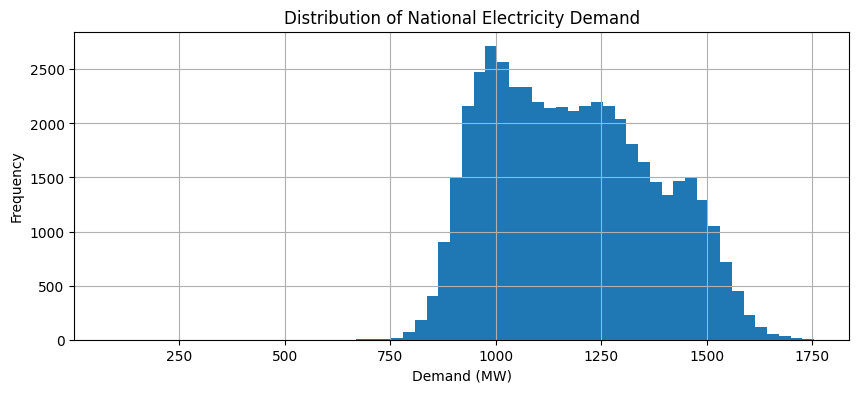

In [8]:
import matplotlib.pyplot as plt

print(df["nat_demand"].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df["nat_demand"].hist(bins=60, ax=ax)
ax.set_title("Distribution of National Electricity Demand")
ax.set_xlabel("Demand (MW)")
ax.set_ylabel("Frequency")
plt.show()

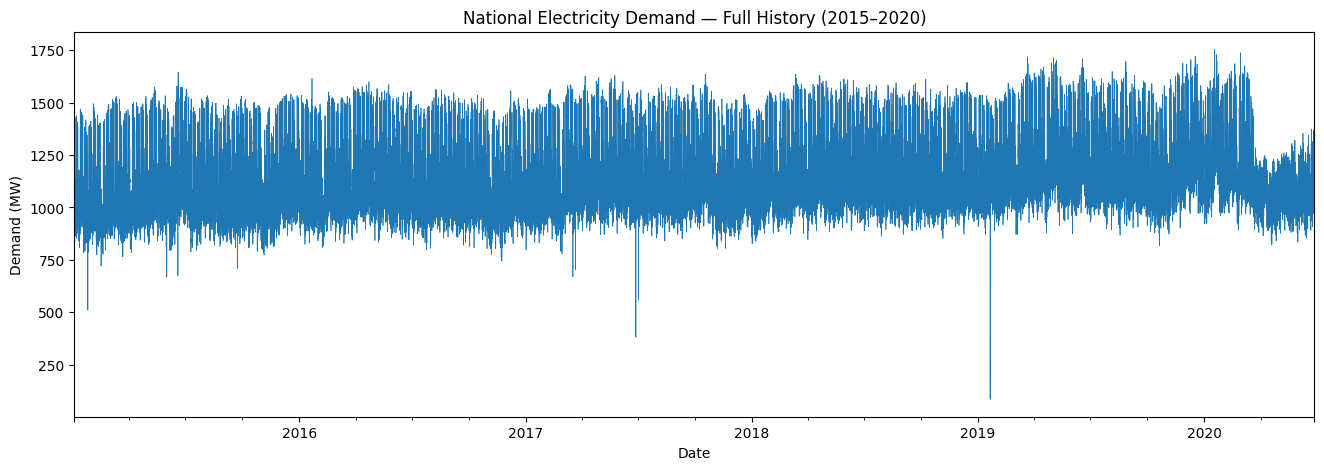

In [9]:
fig, ax = plt.subplots(figsize=(16, 5))
df["nat_demand"].plot(ax=ax, linewidth=0.5)
ax.set_title("National Electricity Demand — Full History (2015–2020)")
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
plt.show()

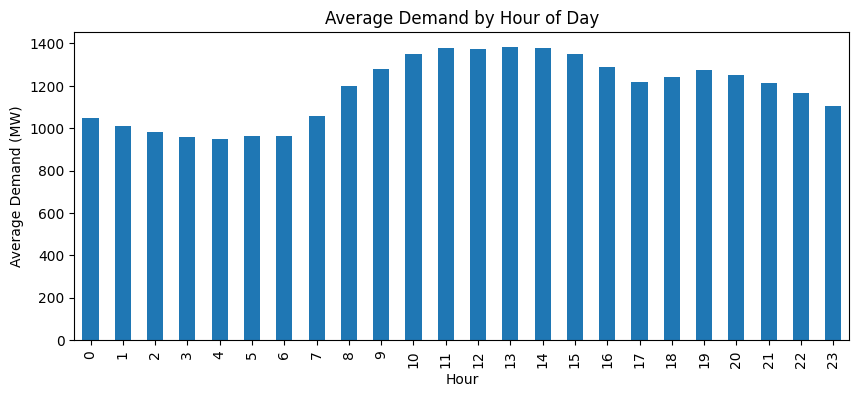

In [10]:
hourly_avg = df.groupby(df.index.hour)["nat_demand"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_avg.plot(kind="bar", ax=ax)
ax.set_title("Average Demand by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Average Demand (MW)")
plt.show()

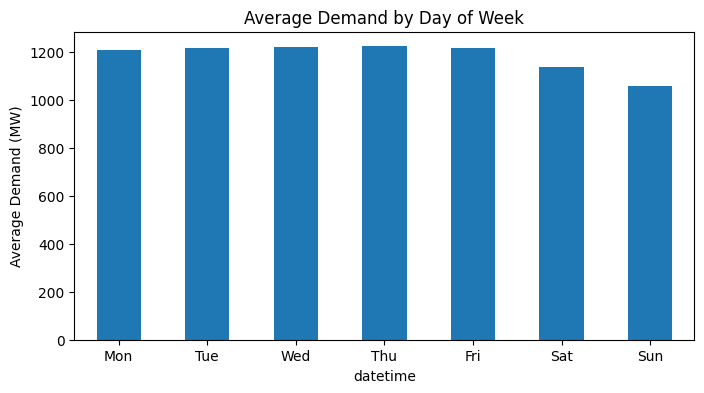

In [11]:
dow_avg = df.groupby(df.index.dayofweek)["nat_demand"].mean()
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))
dow_avg.plot(kind="bar", ax=ax)
ax.set_xticklabels(dow_labels, rotation=0)
ax.set_title("Average Demand by Day of Week")
ax.set_ylabel("Average Demand (MW)")
plt.show()

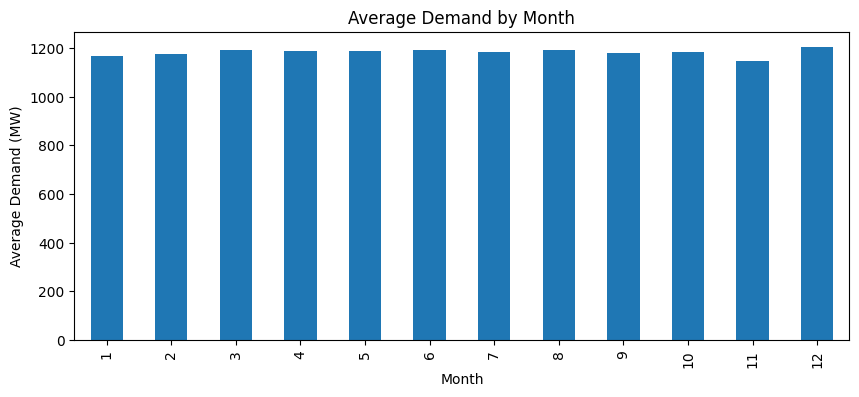

In [12]:
month_avg = df.groupby(df.index.month)["nat_demand"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
month_avg.plot(kind="bar", ax=ax)
ax.set_title("Average Demand by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Demand (MW)")
plt.show()

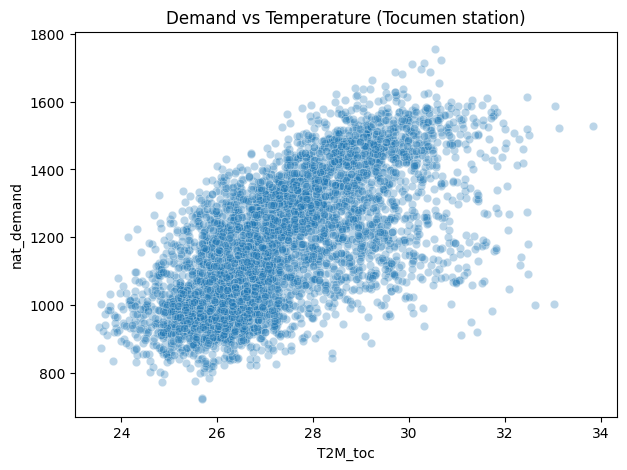

Correlation (T2M_toc vs nat_demand): 0.6528113547259083
Correlation (QV2M_toc vs nat_demand): -0.03670583096882553
Correlation (W2M_toc vs nat_demand): 0.09843540223668917


In [13]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x="T2M_toc", y="nat_demand", alpha=0.3, ax=ax)
ax.set_title("Demand vs Temperature (Tocumen station)")
plt.show()

print("Correlation (T2M_toc vs nat_demand):", df["T2M_toc"].corr(df["nat_demand"]))
print("Correlation (QV2M_toc vs nat_demand):", df["QV2M_toc"].corr(df["nat_demand"]))
print("Correlation (W2M_toc vs nat_demand):", df["W2M_toc"].corr(df["nat_demand"]))

In [14]:
print("Mean demand — holiday vs normal:")
print(df.groupby("holiday")["nat_demand"].mean())

print("\nMean demand — school day vs non-school day:")
print(df.groupby("school")["nat_demand"].mean())

Mean demand — holiday vs normal:
holiday
0    1191.115235
1    1060.086115
Name: nat_demand, dtype: float64

Mean demand — school day vs non-school day:
school
0    1170.292530
1    1187.572329
Name: nat_demand, dtype: float64


In [15]:
print(df["nat_demand"].nsmallest(10))

datetime
2019-01-20 12:00:00     85.1925
2019-01-20 13:00:00    135.7636
2019-01-20 14:00:00    263.6183
2017-06-27 12:00:00    380.5936
2019-01-20 15:00:00    417.4492
2019-01-20 16:00:00    475.8024
2015-01-24 17:00:00    509.8358
2017-07-01 14:00:00    560.7009
2015-06-01 03:00:00    666.7528
2017-03-17 21:00:00    668.9983
Name: nat_demand, dtype: float64


In [16]:
from src.preprocessing import clean_raw_data, chronological_split

df_clean = clean_raw_data(df.reset_index())  # reset_index since df already has datetime as index from Cell 4
splits = chronological_split(df_clean)

print("Train:", splits.train.shape, splits.train.index.min(), "-", splits.train.index.max())
print("Val:  ", splits.val.shape, splits.val.index.min(), "-", splits.val.index.max())
print("Test: ", splits.test.shape, splits.test.index.min(), "-", splits.test.index.max())
print("\nExtreme events flagged:", df_clean["is_extreme_event"].sum())
print(df_clean[df_clean["is_extreme_event"]][["nat_demand"]])

2026-09-09 21:20:23 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-09 21:20:23 | INFO     | src.preprocessing | Chronological split: train=33633 (2015-01-03 01:00:00 to 2018-11-04 09:00:00), val=7207 (2018-11-04 10:00:00 to 2019-08-31 16:00:00), test=7208 (2019-08-31 17:00:00 to 2020-06-27 00:00:00)
Train: (33633, 17) 2015-01-03 01:00:00 - 2018-11-04 09:00:00
Val:   (7207, 17) 2018-11-04 10:00:00 - 2019-08-31 16:00:00
Test:  (7208, 17) 2019-08-31 17:00:00 - 2020-06-27 00:00:00

Extreme events flagged: 4
                     nat_demand
datetime                       
2017-06-27 12:00:00    380.5936
2019-01-20 12:00:00     85.1925
2019-01-20 13:00:00    135.7636
2019-01-20 14:00:00    263.6183
